**PNV3421**

In [2]:
# ===============================
# 1. IMPORTAÇÃO E CARREGAMENTO
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Desligar alguns warnings
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter("ignore", ValueWarning)

# Biblioteca para permitir a leitura do Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Carregar dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset.txt",
                 parse_dates=["date"])
df = df.set_index("date")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [3]:
# ===============================
# 2. TESTE DE ESTACIONARIDADE
# ===============================
result = adfuller(df.value.dropna())
print(f"ADF: {result[0]}")
print(f"p-value: {result[1]}")

plt.rcParams.update({'figure.figsize':(10,7), 'figure.dpi':120})

ADF: 3.14518568930673
p-value: 1.0


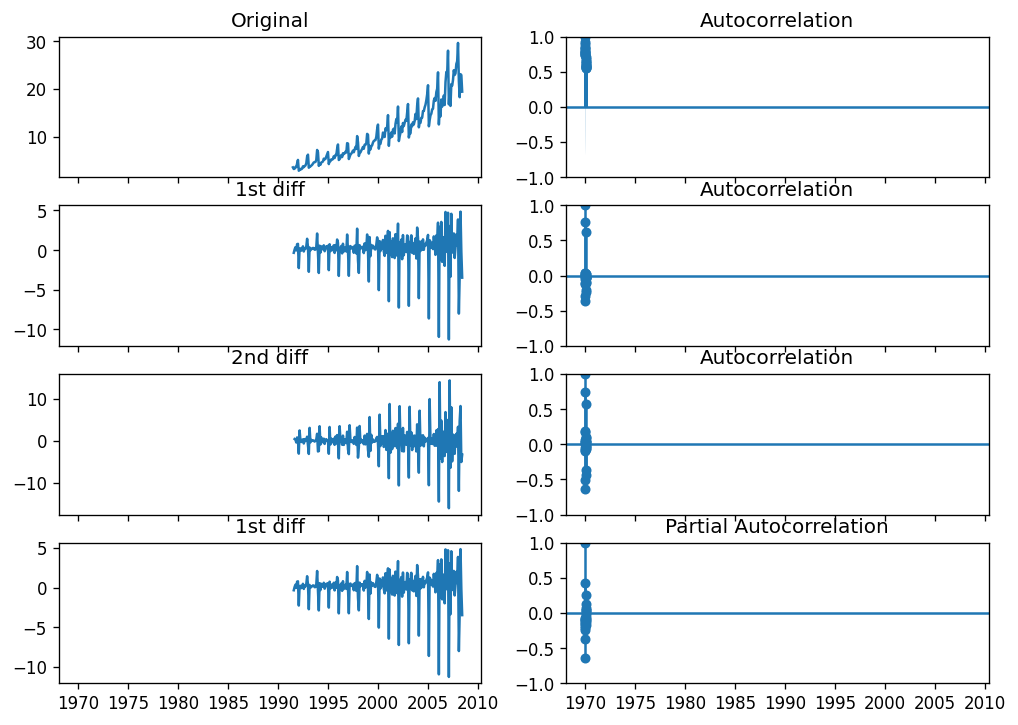

In [4]:
# ===============================
# 3. ACF / PACF E DIFERENCIAÇÃO
# ===============================
fig, axes = plt.subplots(4, 2, sharex=True)

axes[0,0].plot(df.value); axes[0,0].set_title("Original")
plot_acf(df.value, ax=axes[0,1])

axes[1,0].plot(df.value.diff()); axes[1,0].set_title("1st diff")
plot_acf(df.value.diff().dropna(), ax=axes[1,1])

axes[2,0].plot(df.value.diff().diff()); axes[2,0].set_title("2nd diff")
plot_acf(df.value.diff().diff().dropna(), ax=axes[2,1])

axes[3,0].plot(df.value.diff()); axes[3,0].set_title("1st diff")
plot_pacf(df.value.diff().dropna(), ax=axes[3,1])

plt.show()


In [5]:
# ===============================
# 4. AJUSTE DE MODELOS ARIMA
# ===============================
print("\n==== ARIMA(1,1,2) ====\n")
model = ARIMA(df.value, order=(1,1,2))
model_fit = model.fit()
print(model_fit.summary())

print("\n==== ARIMA(1,1,1) ====\n")
model = ARIMA(df.value, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())


==== ARIMA(1,1,2) ====

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  204
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -424.570
Date:                Tue, 25 Nov 2025   AIC                            857.140
Time:                        12:07:44   BIC                            870.393
Sample:                    07-01-1991   HQIC                           862.502
                         - 06-01-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4178      0.356      1.174      0.240      -0.280       1.115
ma.L1         -0.9546      0.377     -2.531      0.011      -1.694      -0.215
ma.L2          0.0969      

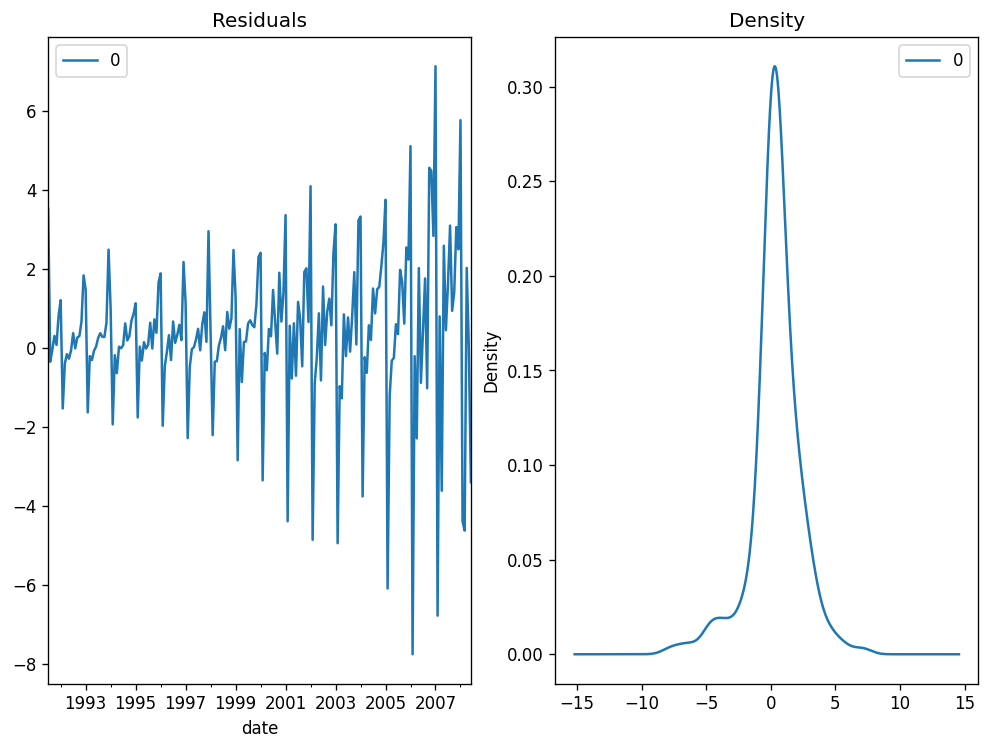

In [6]:
# ===============================
# 5. RESÍDUOS
# ===============================
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

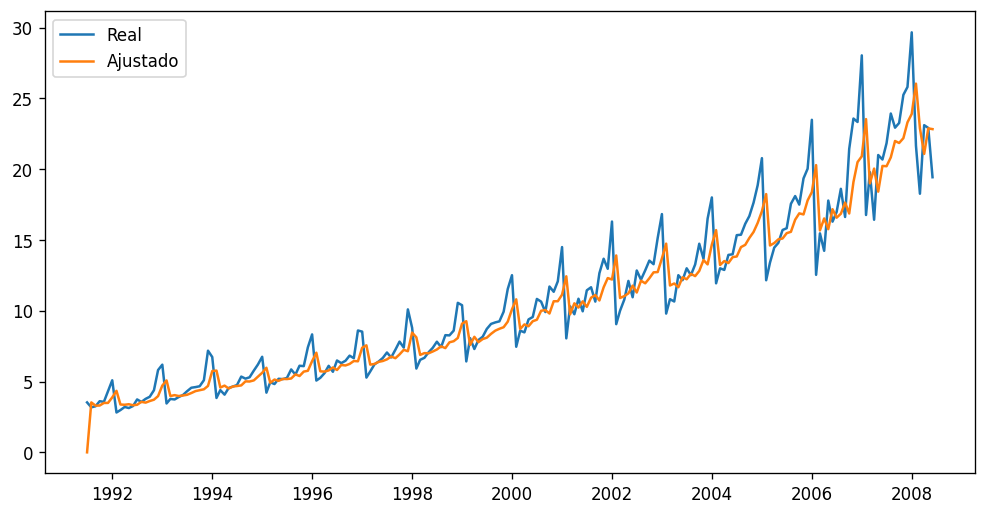

In [7]:
# ===============================
# 6. AJUSTE DENTRO DA AMOSTRA
# ===============================
pred = model_fit.get_prediction()
pred_ci = pred.conf_int()

plt.figure(figsize=(10,5))
plt.plot(df.index, df.value, label="Real")
plt.plot(pred.predicted_mean.index, pred.predicted_mean, label="Ajustado")
plt.legend()
plt.show()

# OBS: Usar get_prediction() no conjunto inteiro permite ver como o modelo se ajusta à série, e ver se o modelo está capturando a dinâmica geral.
# Mas isso não é avaliação de desempenho. A boa prática real é usar a previsão "out-of-sample", e testar  testando o modelo em dados que o modelo não viu.

In [8]:
print(len(df))

204


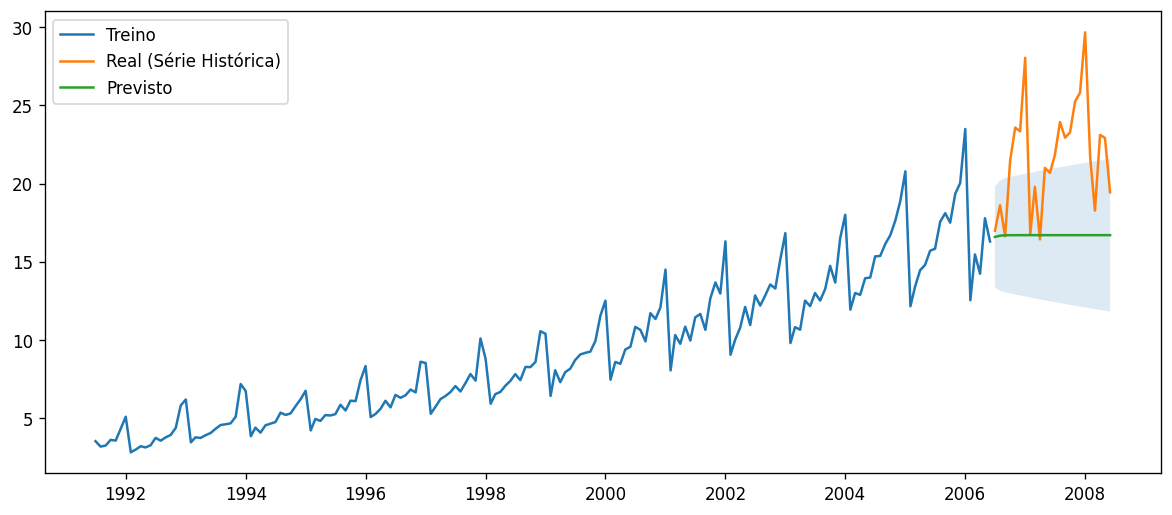

In [9]:
# ===============================
# 7. TREINO / TESTE
# ===============================
train = df.value[:180]
test = df.value[180:]

# ARIMA 1,1,1 para previsão no TESTE
model = ARIMA(train, order=(1,1,1))
fitted = model.fit()

pred = fitted.get_forecast(steps=len(test))
fc = pred.predicted_mean
conf = pred.conf_int()

fc_series = pd.Series(fc, index=test.index)
lower = pd.Series(conf.iloc[:,0], index=test.index)
upper = pd.Series(conf.iloc[:,1], index=test.index)

plt.figure(figsize=(12,5))
plt.plot(train, label="Treino")
plt.plot(test, label="Real (Série Histórica)")
plt.plot(fc_series, label="Previsto")
plt.fill_between(test.index, lower, upper, alpha=.15)
plt.legend()
plt.show()


==== ARIMA(3,2,1) ====

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  180
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -352.383
Date:                Tue, 25 Nov 2025   AIC                            714.765
Time:                        12:07:46   BIC                            730.674
Sample:                    07-01-1991   HQIC                           721.217
                         - 06-01-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4511      0.101     -4.445      0.000      -0.650      -0.252
ar.L2         -0.2520      0.112     -2.243      0.025      -0.472      -0.032
ar.L3         -0.2112      

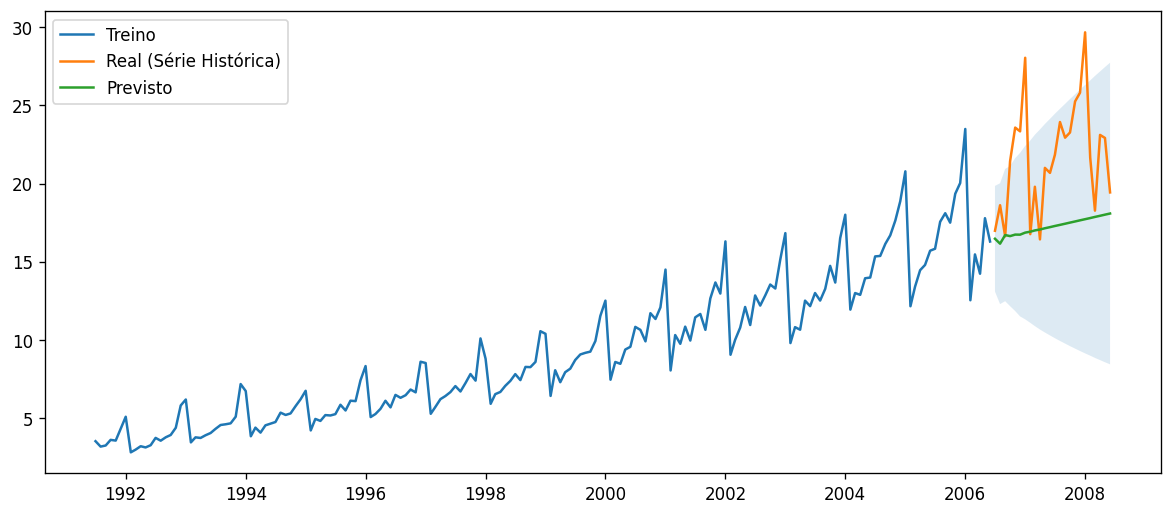

In [10]:
# ===============================
# 8. ARIMA 3,2,1 TREINADO
# ===============================
print("\n==== ARIMA(3,2,1) ====\n")
model = ARIMA(train, order=(3,2,1))
fitted = model.fit()
print(fitted.summary())

pred = fitted.get_forecast(steps=len(test))
fc = pred.predicted_mean
conf = pred.conf_int()

fc_series = pd.Series(fc, index=test.index)
lower = pd.Series(conf.iloc[:,0], index=test.index)
upper = pd.Series(conf.iloc[:,1], index=test.index)

plt.figure(figsize=(12,5))
plt.plot(train, label="Treino")
plt.plot(test, label="Real (Série Histórica)")
plt.plot(fc_series, label="Previsto")
plt.fill_between(test.index, lower, upper, alpha=.15)
plt.legend()
plt.show()

In [11]:
# ===============================
# 9. MÉTRICAS
# ===============================
def forecast_accuracy(forecast, actual):
    forecast = np.asarray(forecast)
    actual = np.asarray(actual)

    mape  = np.mean(np.abs(forecast - actual) / np.abs(actual))
    me    = np.mean(forecast - actual)
    mae   = np.mean(np.abs(forecast - actual))
    mpe   = np.mean((forecast - actual) / actual)
    rmse  = np.sqrt(np.mean((forecast - actual)**2))
    corr  = np.corrcoef(forecast, actual)[0,1]

    mins  = np.minimum(forecast, actual)
    maxs  = np.maximum(forecast, actual)
    minmax = 1 - np.mean(mins/maxs)

    erro = forecast - actual
    acf1 = acf(erro, fft=False)[1]

    return {'mape':mape,'me':me,'mae':mae,'mpe':mpe,
            'rmse':rmse,'corr':corr,'minmax':minmax,'acf1':acf1}

print("\nMÉTRICAS:")
print(forecast_accuracy(fc_series.values, test.values))


MÉTRICAS:
{'mape': np.float64(0.1918416068891394), 'me': np.float64(-4.4785781846505905), 'mae': np.float64(4.551357143111459), 'mpe': np.float64(-0.18743219365834418), 'rmse': np.float64(5.564131616869187), 'corr': np.float64(0.3328655246876161), 'minmax': np.float64(0.1917772343481422), 'acf1': np.float64(0.25189272511135863)}


In [14]:
# ===============================
# 10. AUTO-ARIMA
# ===============================
!pip install pmdarima
import pmdarima as pm

model = pm.auto_arima(
    df.value,
    seasonal=True,
    m=12,                    # se mensal
    stepwise=True,           # rápido e estável
    trace=True,              # mostra a busca (estilo Box-Jenkins)
    error_action='ignore',
    suppress_warnings=True
)

print(model.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.6 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=526.837, Time=1.52 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=659.245, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=560.558, Time=0.15 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=529.539, Time=0.33 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=525.356, Time=1.21 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=551.838, Time=0.29 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=526.365, Time=3.63 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=530.219, Time=2.49 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=inf, Time=4.12 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=527.568, Time=0.95 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=529.582, Time=0.82 sec
 ARIMA(3,1,2)(0,1,1)[12]             : AIC=520.313, Time=1.06 sec
 ARIMA(3,1,2)(0,1,0)[12]             : AIC=544.911, Time=0.41 sec
 ARIMA(3,1,2)(1,1,1)[12